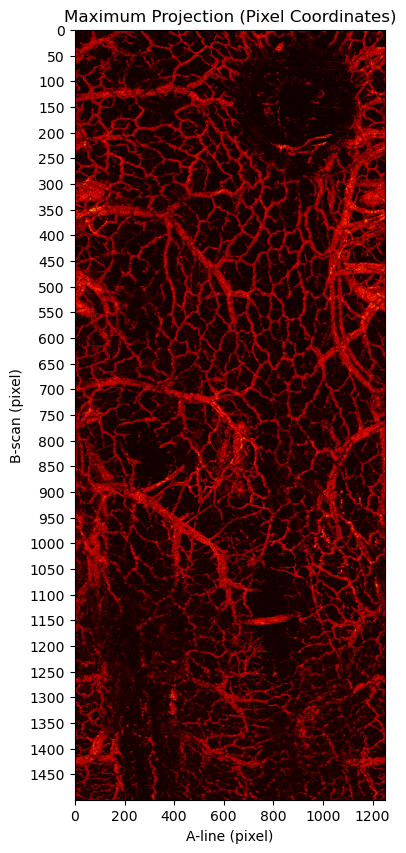

In [4]:
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import numpy as np
import Image_Reconstruction as ir
import matplotlib.pyplot as plt
import os

#file = 'D:\\WORK\\Statistical-difference-analysis-in-vascular-imaging\\data\\data_normal.dat'
#file = 'D:\\WORK\\Statistical-difference-analysis-in-vascular-imaging\\data\\data_normal2.dat'
file = "D:\\WORK\\Statistical-difference-analysis-in-vascular-imaging\\Installments\\暂存\\1_1170data.dat"
#file = "D:\\WORK\\Statistical-difference-analysis-in-vascular-imaging\\data\\37data.dat"

data = ir.Reconstruction532(file)

P_map = ir.Partial_Map(data, [215, 320], 100)

# 绘制
plt.figure(figsize=(4,10))

plt.imshow(
    P_map[0],
    cmap='hot',
    aspect='auto'   # 或 'equal'
)

plt.yticks(np.arange(0, 1500, 50))

plt.xlabel("A-line (pixel)")
plt.ylabel("B-scan (pixel)")
plt.title("Maximum Projection (Pixel Coordinates)")
plt.show()

data = data ** 2

In [5]:
# 选取ROI，给出肿瘤区域的上下界
#Limit = [[0,250], [350,550], [1150,1300]]
Limit = [[0,250]]
#Limit = []

In [6]:
def Calculate_average_thickness(Tumor_Data):
    def aline_thickness(aline, prominence=0.05, smooth_sigma=2):
        # 平滑（去 speckle）
        aline = gaussian_filter1d(aline.astype(float), sigma=smooth_sigma)
        aline = aline[175:350]

        # 归一化
        aline = aline - aline.min()
        aline = aline / (aline.max() + 1e-8)

        # 找峰 + FWHM信息
        peaks, _ = find_peaks(
            aline,
            prominence=prominence,
            width=1
        )
        if len(peaks) <= 1:
            distance = 0
        else:
            distance = peaks[-1] - peaks[0]

        return distance
    
    sizeZ, sizeB, sizeA = Tumor_Data.shape

    Thickness = []
    for i in range(sizeZ):
        Bscan = Tumor_Data[i, :, :]

        Bscan_data = []
        for j in range(sizeB):
            Total_thickness = aline_thickness(Bscan[j, :])
            Bscan_data.append(Total_thickness)

        Thickness.append(np.mean(Bscan_data))

    return np.array(Thickness)

def split_selected_and_random_rest(data, limits, axis=0, total_range=None, seed=None):
    if total_range is None:
        total_range = [0, data.shape[axis]]

    if seed is not None:
        np.random.seed(seed)

    # ===== 排序 limits =====
    limits = sorted(limits)

    # ===== 计算 ROI 总长度 =====
    roi_length = sum(end - start for start, end in limits)

    # ===== 构造 mask（标记哪些位置是ROI）=====
    length = total_range[1] - total_range[0]
    mask = np.zeros(length, dtype=bool)

    for start, end in limits:
        mask[start:end] = True

    # ===== 可选位置（非ROI）=====
    available_indices = np.where(~mask)[0]

    if len(available_indices) == 0:
        raise ValueError("没有可用的非ROI区域")

    # ===== 随机选取与 ROI 长度一致的 index =====
    if roi_length > len(available_indices):
        raise ValueError("非ROI区域不足以匹配ROI长度")

    chosen_indices = np.random.choice(available_indices, size=roi_length, replace=False)
    chosen_indices.sort()

    # ===== 把离散 index 转为连续区间 =====
    def indices_to_ranges(indices):
        ranges = []
        start = indices[0]
        prev = indices[0]

        for i in indices[1:]:
            if i != prev + 1:
                ranges.append([start, prev + 1])
                start = i
            prev = i

        ranges.append([start, prev + 1])
        return ranges

    random_ranges = indices_to_ranges(chosen_indices)

    # ===== 切片函数 =====
    def extract(ranges):
        slices = []
        for start, end in ranges:
            idx = [slice(None)] * data.ndim
            idx[axis] = slice(start, end)
            slices.append(data[tuple(idx)])
        return np.concatenate(slices, axis=axis) if slices else None

    selected_data = extract(limits)
    random_rest_data = extract(random_ranges)

    return selected_data, random_rest_data

if not Limit:
    Anti_ROI_thickness = Calculate_average_thickness(data)

    filename = os.path.splitext(os.path.basename(file))[0]
    cwd = os.getcwd()
    save_dir = os.path.join(cwd, "Output", "quan", filename)
    os.makedirs(save_dir, exist_ok=True)

    np.savetxt(os.path.join(save_dir, f"Anti_ROI_thickness.txt"), Anti_ROI_thickness)

else:
    # 获取ROI区域和非ROI区域
    ROI_data, Anti_ROI_data = split_selected_and_random_rest(data, Limit)

    # 计算厚度
    ROI_thickness = Calculate_average_thickness(ROI_data)
    Anti_ROI_thickness = Calculate_average_thickness(Anti_ROI_data)


    filename = os.path.splitext(os.path.basename(file))[0]
    cwd = os.getcwd()
    save_dir = os.path.join(cwd, "Output", filename)
    os.makedirs(save_dir, exist_ok=True)

    np.savetxt(os.path.join(save_dir, f"ROI_thickness.txt"), ROI_thickness)
    np.savetxt(os.path.join(save_dir, f"Anti_ROI_thickness.txt"), Anti_ROI_thickness)

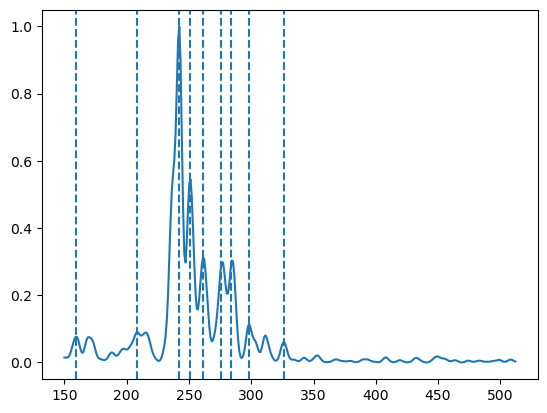

In [68]:
def aline_thickness(aline, prominence=0.05, smooth_sigma=2):
    aline = aline[150:]
    
    # 平滑（去 speckle）
    aline = gaussian_filter1d(aline.astype(float), sigma=smooth_sigma)

    # 归一化
    aline = aline - aline.min()
    aline = aline / (aline.max() + 1e-8)

    # 找峰 + FWHM信息
    peaks, _ = find_peaks(
        aline,
        prominence=prominence,
        width=1
    )
    if len(peaks) <= 1:
        distance = 0
    else:
        distance = peaks[-1] - peaks[0]

    x = np.linspace(150, 512, 362)

    plt.plot(x, aline)

    for v in peaks:
        plt.axvline(x=v+150, linestyle='--')

Bscan = data[200, :, :]
Aline = Bscan[10, :]

aline_thickness(Aline)